# Modello CAMS da Sentinel-5P + ERA5

**Obiettivo.** Costruire **quattro modelli di regressione** che stimano gli inquinanti **CAMS**
(`NO₂`, `O₃`, `PM10`, `PM2.5`) unendo due famiglie di predittori:

| Famiglia | Variabili | Trattamento temporale |
|---|---|---|
| **Sentinel-5P** | il proxy ottimale per ciascun inquinante | **lag + media mobile retrospettiva** come selezionati in `analisi_correlazione_temporale.ipynb` |
| **ERA5** | `SSRD`, `1/BLH`, `T2m`, `TP`, `vento` | **giorno *t*, nessun lag, nessuna media mobile** (come in `analisi_correlazione_era5_cams.ipynb`) |

L'unione avviene per chiave **`(data, punto_id)`**.

## Vincoli metodologici applicati

1. **Lag solo a Sentinel-5P.** ERA5 resta al giorno *t*; il target CAMS resta al giorno *t*.
   Lo `shift` è applicato **esclusivamente** ai predittori satellitari.
2. **Risoluzione originale di Sentinel-5P.** Nessun ricampionamento, nessuna aggregazione
   spaziale, nessuna interpolazione: ogni `punto_id` conserva il valore del **pixel S5P nativo**.
   L'unione è fatta **a livello di punto**, quindi è ERA5 (griglia 0.25°, più grossolana) a essere
   replicato sui punti — mai il contrario. Verifica quantitativa nella § 4.3.
3. **Nessun leakage.** Medie mobili **solo retrospettive** (mai giorni futuri), calcolate su un
   **calendario giornaliero continuo per punto**, e validazione temporale **rolling-origin** con
   **embargo** pari all'ampiezza della finestra dei predittori (§ 6).
4. **Controlli di qualità obbligatori:** duplicati su `(data, punto_id)`, valori mancanti, **VIF**.

## Avvertenza sull'interpretazione (vale per tutti i risultati)

Il target è l'**output del modello CAMS**, non una misura strumentale. CAMS è guidato dalla
meteorologia IFS/ECMWF, la stessa famiglia da cui deriva ERA5: una quota della bontà di
adattamento riflette l'**accoppiamento interno** tra i due prodotti, non una relazione
osservata in modo indipendente. Le colonne `arpa_*` (misure di stazione), presenti nel file
sorgente, **non** sono usate qui: la loro modellazione è un esercizio distinto.

> I due notebook esplorativi non vengono modificati: questo notebook li **legge** (per recuperare
> le configurazioni ottimali) e scrive i propri output in una cartella separata.

## 1. Setup e configurazione

Tutti i parametri del modello sono raccolti qui: file di input, cartella di output, insieme dei
predittori ERA5, e la configurazione `(proxy S5P, lag, finestra MA)` per ciascun inquinante.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from IPython.display import display, Markdown, Math

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
pd.set_option('display.float_format', lambda v: f"{v:,.4f}")

# ── Input ────────────────────────────────────────────────────────────────────
# File unificato (CAMS + ARPA + Sentinel-5P + ERA5) sulla stessa chiave (data, punto_id).
CSV_UNIFICATO = Path('serie_temporali_giorno_cams_arpa_s5_era5.csv')
# Fallback: due file separati da unire esplicitamente.
CSV_S5P_FALLBACK  = Path('serie_temporali_giornaliero_corretto.csv')
CSV_ERA5_FALLBACK = Path('serie_temporali_giornaliero_era5_corretto.csv')

# Risultati dei due notebook esplorativi (sola lettura)
DIR_ESPLORATIVA = Path('risultati_correlazione')
CSV_RIEPILOGO_TEMPORALE = DIR_ESPLORATIVA / 'riepilogo_giornaliero.csv'

# ── Output (cartella dedicata: non sovrascrive i risultati esplorativi) ──────
OUT_DIR = Path('risultati_modello')
OUT_DIR.mkdir(exist_ok=True)

# ── Target CAMS ──────────────────────────────────────────────────────────────
TARGET = {'NO2': 'cams_no2', 'O3': 'cams_o3', 'PM10': 'cams_pm10', 'PM25': 'cams_pm25'}

# ── Predittori ERA5: gli stessi selezionati nel notebook ERA5-CAMS ───────────
# `era5_blh_max` è escluso per collinearità con `era5_blh` (VIF ~8.9 in entrambi);
# la BLH entra in forma inversa 1/BLH (relazione fisica di diluizione).
FEATURES_ERA5 = ['era5_ssrd_MJ', 'inv_blh', 'era5_t2m_C', 'era5_tp_mm', 'vento_velocita']

# ── Proxy S5P disponibili per ciascun inquinante (come nel notebook temporale) ──
PROXY_S5P = {
    'NO2':  {'NO2_TROPOMI': 's5p_no2', 'Colonna_O3': 's5p_o3', 'Aerosol_Index': 's5p_pm10',
             'SO2_proxy': 's5p_so2', 'HCHO_proxy': 's5p_hcho'},
    'O3':   {'Colonna_O3': 's5p_o3', 'NO2_proxy': 's5p_no2', 'HCHO_proxy': 's5p_hcho'},
    'PM10': {'Aerosol_Index': 's5p_pm10', 'NO2_proxy': 's5p_no2', 'SO2_proxy': 's5p_so2',
             'HCHO_proxy': 's5p_hcho'},
    'PM25': {'Aerosol_Index': 's5p_pm25', 'NO2_proxy': 's5p_no2', 'SO2_proxy': 's5p_so2',
             'HCHO_proxy': 's5p_hcho'},
}

# ── Configurazione di riserva (usata se il riepilogo esplorativo non è leggibile) ──
CONFIG_S5P_DEFAULT = {
    'NO2':  {'proxy': 'NO2_TROPOMI',   'lag': 7, 'ma': 14},
    'O3':   {'proxy': 'NO2_proxy',     'lag': 0, 'ma': 14},
    'PM10': {'proxy': 'Aerosol_Index', 'lag': 3, 'ma': 14},
    'PM25': {'proxy': 'NO2_proxy',     'lag': 7, 'ma': 14},
}

# ── Validazione temporale ────────────────────────────────────────────────────
N_FOLD = 5             # numero di blocchi di test (rolling-origin, finestra espansiva)
QUOTA_TRAIN_INIZIALE = 0.40   # frazione del calendario riservata al primo training

ETICHETTE = {
    'era5_ssrd_MJ': 'SSRD [MJ/m²]', 'inv_blh': '1/BLH [1/m]', 'era5_t2m_C': 'T2m [°C]',
    'era5_tp_mm': 'TP [mm]', 'vento_velocita': 'Vento [m/s]',
    'cams_no2': 'NO₂', 'cams_o3': 'O₃', 'cams_pm10': 'PM10', 'cams_pm25': 'PM2.5',
}
SIMBOLI = {'era5_ssrd_MJ': 'SSRD', 'inv_blh': '(1/BLH)', 'era5_t2m_C': 'T2m',
           'era5_tp_mm': 'TP', 'vento_velocita': 'WS'}

COLORI = {'s5p': '#C0504D', 'era5': '#3A7DC9', 'train': '#3A7DC9',
          'embargo': '#BFBFBF', 'test': '#E07B39'}

print('Output ->', OUT_DIR.resolve())

Output -> C:\Users\nsarmientoospina\Documents\REG4IA\risultati_modello


### 1.1 Configurazione lag / media mobile ereditata dal notebook temporale

I valori di **lag** e **finestra di media mobile** non vengono ri-ottimizzati qui: sono letti da
`risultati_correlazione/riepilogo_giornaliero.csv`, cioè la combinazione che massimizza |r| in
`analisi_correlazione_temporale.ipynb`. Se il file non è disponibile si usa la configurazione di
riserva, identica nei valori.

Ri-ottimizzare i lag su tutto il periodo e poi validare sullo stesso periodo introdurrebbe
**selection leakage**: la scelta è quindi presa a monte e qui trattata come **dato fissato**.

In [2]:
def carica_configurazione_s5p(path, proxy_disponibili, default):
    # Legge (proxy, lag, MA) ottimali dal riepilogo del notebook temporale.
    cfg = {k: dict(v) for k, v in default.items()}
    origine = 'configurazione di riserva (file non trovato)'
    if path.exists():
        try:
            riep = pd.read_csv(path, sep=';', decimal=',')
            colonne = {'Inquinante', 'Proxy S5P', 'Lag [giorni]', 'MA [giorni]'}
            if colonne.issubset(riep.columns):
                for _, r in riep.iterrows():
                    var = str(r['Inquinante'])
                    proxy = str(r['Proxy S5P'])
                    if var in cfg and proxy in proxy_disponibili[var]:
                        cfg[var] = {'proxy': proxy,
                                    'lag': int(r['Lag [giorni]']),
                                    'ma': int(r['MA [giorni]'])}
                origine = f'letta da {path}'
            else:
                origine = f'colonne inattese in {path}: uso la configurazione di riserva'
        except Exception as e:
            origine = f'errore di lettura ({e}): uso la configurazione di riserva'

    for var, c in cfg.items():
        c['s5p_col'] = proxy_disponibili[var][c['proxy']]
        c['nome_feature'] = f"{c['s5p_col']}_lag{c['lag']}_ma{c['ma']}"
    return cfg, origine


CONFIG_S5P, ORIGINE_CONFIG = carica_configurazione_s5p(
    CSV_RIEPILOGO_TEMPORALE, PROXY_S5P, CONFIG_S5P_DEFAULT)

print('Origine configurazione:', ORIGINE_CONFIG, '\n')
tab_cfg = pd.DataFrame([
    {'Inquinante': v, 'Target CAMS': TARGET[v], 'Proxy S5P': c['proxy'],
     'Colonna S5P': c['s5p_col'], 'Lag [gg]': c['lag'], 'MA [gg]': c['ma'],
     'Feature S5P': c['nome_feature'],
     'Ampiezza finestra [gg]': c['lag'] + c['ma']}
    for v, c in CONFIG_S5P.items()])
display(tab_cfg)

Origine configurazione: letta da risultati_correlazione\riepilogo_giornaliero.csv 



,Inquinante,Target CAMS,Proxy S5P,Colonna S5P,Lag [gg],MA [gg],Feature S5P,Ampiezza finestra [gg]
0,NO2,cams_no2,NO2_TROPOMI,s5p_no2,7,14,s5p_no2_lag7_ma14,21
1,O3,cams_o3,NO2_proxy,s5p_no2,0,14,s5p_no2_lag0_ma14,14
2,PM10,cams_pm10,Aerosol_Index,s5p_pm10,3,14,s5p_pm10_lag3_ma14,17
3,PM25,cams_pm25,NO2_proxy,s5p_no2,7,14,s5p_no2_lag7_ma14,21


## 2. Caricamento e controllo qualità

Il file unificato contiene già CAMS, Sentinel-5P ed ERA5 sulla stessa chiave `(data, punto_id)`.
Se non è presente, i due blocchi vengono letti da file separati e uniti nella § 3.

Controlli eseguiti in questa sezione:
- **duplicati** su `(data, punto_id)` — verificando se le righe duplicate sono *copie identiche*
  (artefatto di ingestione, rimovibile) oppure *valori discordanti* (conflitto reale, bloccante);
- **copertura temporale e spaziale** (calendario continuo, punti attesi);
- **valori mancanti** per colonna.

In [3]:
COLONNE_UTILI = ['data', 'punto_id', 'lon', 'lat', 'vento_velocita', 'vento_direzione',
                 'cams_no2', 'cams_o3', 'cams_pm10', 'cams_pm25',
                 's5p_no2', 's5p_o3', 's5p_pm10', 's5p_pm25', 's5p_so2', 's5p_hcho',
                 'era5_t2m', 'era5_u10', 'era5_v10', 'era5_ssrd', 'era5_tp',
                 'era5_blh', 'era5_blh_max']


def leggi_csv(path, colonne=None):
    # I CSV usano ';' come separatore e ',' come separatore decimale; lettura robusta.
    def _read(dec):
        disponibili = pd.read_csv(path, sep=';', encoding='utf-8-sig', nrows=0).columns
        usecols = [c for c in colonne if c in disponibili] if colonne else None
        return pd.read_csv(path, sep=';', encoding='utf-8-sig', decimal=dec, usecols=usecols)

    df = _read('.')
    if not pd.api.types.is_numeric_dtype(df['lon']):
        df = _read(',')
    df['data'] = pd.to_datetime(df['data'])
    df['punto_id'] = df['punto_id'].astype(int)
    return df


def controlla_duplicati(df, etichetta):
    # Duplicati su (data, punto_id): tollerati solo se copie perfettamente identiche.
    n_dup = int(df.duplicated(subset=['data', 'punto_id']).sum())
    if n_dup == 0:
        print(f'[{etichetta}] duplicati (data, punto_id): 0 — OK')
        return df

    coinvolte = df[df.duplicated(subset=['data', 'punto_id'], keep=False)]
    n_gruppi = coinvolte.groupby(['data', 'punto_id'], sort=False).ngroups
    n_gruppi_identici = int((coinvolte.groupby(['data', 'punto_id'], sort=False)
                                      .apply(lambda g: len(g.drop_duplicates()) == 1)).sum())
    date_coinvolte = sorted(coinvolte['data'].dt.date.unique())

    print(f'[{etichetta}] duplicati (data, punto_id): {n_dup:,} righe in eccesso '
          f'({n_gruppi:,} chiavi, date: {", ".join(map(str, date_coinvolte[:5]))}'
          f'{" ..." if len(date_coinvolte) > 5 else ""})')
    assert n_gruppi_identici == n_gruppi, (
        f'[{etichetta}] {n_gruppi - n_gruppi_identici} chiavi duplicate con valori DISCORDANTI: '
        'conflitto reale, va risolto a monte (non è un artefatto di ingestione).')
    print(f'  -> tutte le {n_gruppi:,} chiavi sono copie identiche: rimozione sicura '
          'con drop_duplicates().')
    df = df.drop_duplicates(subset=['data', 'punto_id']).reset_index(drop=True)
    print(f'  -> righe dopo deduplicazione: {len(df):,}')
    return df


if CSV_UNIFICATO.exists():
    print(f'Sorgente: file unificato {CSV_UNIFICATO}')
    base = leggi_csv(CSV_UNIFICATO, COLONNE_UTILI)
    base = controlla_duplicati(base, 'UNIFICATO')
    SORGENTE = 'unificata'
else:
    print('File unificato assente: leggo i due blocchi da file separati.')
    base_s5p = controlla_duplicati(leggi_csv(CSV_S5P_FALLBACK), 'S5P/CAMS')
    base_era5 = controlla_duplicati(leggi_csv(CSV_ERA5_FALLBACK), 'ERA5')
    comuni = [c for c in base_era5.columns
              if c in base_s5p.columns and c not in ('data', 'punto_id')]
    base = base_s5p.merge(base_era5.drop(columns=comuni), on=['data', 'punto_id'],
                          how='inner', validate='one_to_one')
    SORGENTE = 'due file uniti'

base = base.sort_values(['punto_id', 'data']).reset_index(drop=True)
print(f'\nShape: {base.shape} | sorgente: {SORGENTE}')
base.head(3)

Sorgente: file unificato serie_temporali_giorno_cams_arpa_s5_era5.csv
[UNIFICATO] duplicati (data, punto_id): 1,244 righe in eccesso (1,244 chiavi, date: 2025-08-24)
  -> tutte le 1,244 chiavi sono copie identiche: rimozione sicura con drop_duplicates().
  -> righe dopo deduplicazione: 454,060

Shape: (454060, 23) | sorgente: unificata


,data,punto_id,lon,lat,vento_velocita,vento_direzione,cams_no2,cams_o3,cams_pm10,cams_pm25,...,s5p_pm25,s5p_so2,s5p_hcho,era5_t2m,era5_u10,era5_v10,era5_ssrd,era5_tp,era5_blh,era5_blh_max
0,2025-01-01,0,10.2321,46.6205,0.5228,357.2186,3.4751,58.7846,8.0082,5.2332,...,-1.0515,-0.0012,-0.0002,265.2479,0.0254,-0.5222,"1,365,568.0000",0.0000,9.3751,9.9352
1,2025-01-02,0,10.2321,46.6205,1.1744,241.9325,4.9496,45.2871,11.1140,7.6637,...,0.4225,-0.0040,-0.0001,265.9220,1.0363,0.5526,"945,920.0000",0.0001,16.9927,27.1365
2,2025-01-03,0,10.2321,46.6205,2.0319,345.3114,4.3056,57.5216,2.8028,2.0788,...,-1.3358,-0.0007,-0.0000,261.6995,0.5152,-1.9655,"1,367,296.0000",0.0005,45.3401,101.5657


In [4]:
# ── Copertura temporale e spaziale ───────────────────────────────────────────
CALENDARIO = pd.date_range(base['data'].min(), base['data'].max(), freq='D')
PUNTI = np.sort(base['punto_id'].unique())

print(f"Periodo          : {base['data'].min().date()} -> {base['data'].max().date()}")
print(f"Giorni distinti  : {base['data'].nunique():,}  (calendario continuo: {len(CALENDARIO):,})")
print(f"Punti distinti   : {len(PUNTI):,}")
print(f"Righe            : {len(base):,}   (attese punti x giorni = {len(PUNTI) * len(CALENDARIO):,})")

mancanti_griglia = len(PUNTI) * len(CALENDARIO) - len(base)
print(f"Celle (punto, giorno) assenti dalla griglia: {mancanti_griglia:,} "
      f"({100 * mancanti_griglia / (len(PUNTI) * len(CALENDARIO)):.2f}%)")

righe_per_punto = base.groupby('punto_id').size()
print(f"Righe per punto  : min {righe_per_punto.min():,} | max {righe_per_punto.max():,}")

Periodo          : 2025-01-01 -> 2025-12-31
Giorni distinti  : 365  (calendario continuo: 365)
Punti distinti   : 1,244
Righe            : 454,060   (attese punti x giorni = 454,060)
Celle (punto, giorno) assenti dalla griglia: 0 (0.00%)
Righe per punto  : min 365 | max 365


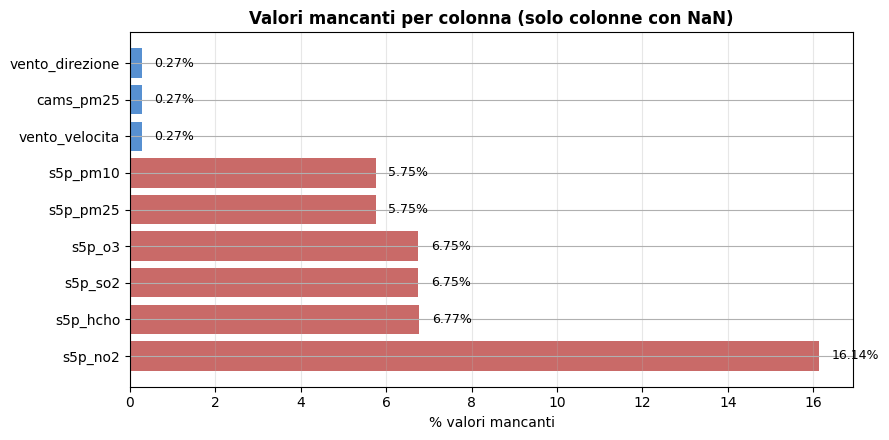

,% NaN
s5p_no2,16.1350
s5p_hcho,6.7720
s5p_so2,6.7500
s5p_o3,6.7500
s5p_pm25,5.7530
s5p_pm10,5.7530
vento_velocita,0.2740
cams_pm25,0.2740
vento_direzione,0.2740


Le lacune Sentinel-5P sono dovute alla copertura nuvolosa e al filtro di qualità delle retrieval: sono strutturali, non un difetto di ingestione.


In [5]:
# ── Valori mancanti per colonna ──────────────────────────────────────────────
na_col = (base.isna().mean() * 100).round(3).sort_values(ascending=False)
na_col = na_col[na_col > 0]

fig, ax = plt.subplots(figsize=(9, 4.5))
colori = [COLORI['s5p'] if c.startswith('s5p_') else COLORI['era5'] for c in na_col.index]
ax.barh(na_col.index, na_col.values, color=colori, alpha=0.85)
for i, v in enumerate(na_col.values):
    ax.text(v + 0.3, i, f'{v:.2f}%', va='center', fontsize=9)
ax.set_xlabel('% valori mancanti')
ax.set_title('Valori mancanti per colonna (solo colonne con NaN)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'qc_valori_mancanti.png', dpi=150, bbox_inches='tight')
plt.show()

display(na_col.to_frame('% NaN'))
print('Le lacune Sentinel-5P sono dovute alla copertura nuvolosa e al filtro di qualità '
      'delle retrieval: sono strutturali, non un difetto di ingestione.')

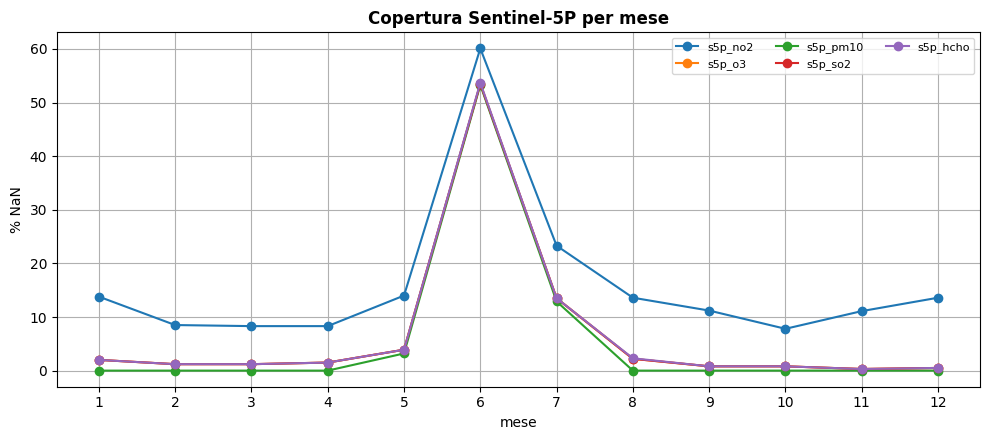

,s5p_no2,s5p_o3,s5p_pm10,s5p_so2,s5p_hcho
data,,,,,
1,13.8000,2.0000,0.0000,2.0000,2.0000
2,8.5000,1.2000,0.0000,1.2000,1.2000
3,8.3000,1.2000,0.0000,1.2000,1.2000
4,8.3000,1.5000,0.0000,1.5000,1.5000
5,14.0000,3.9000,3.2000,3.9000,3.9000
6,60.1000,53.5000,53.3000,53.5000,53.7000
7,23.3000,13.5000,12.9000,13.5000,13.5000
8,13.6000,2.2000,0.0000,2.2000,2.3000
9,11.2000,0.8000,0.0000,0.8000,0.8000


In [6]:
# ── Lacune Sentinel-5P per mese: dove la copertura satellitare si assottiglia ──
mesi = base['data'].dt.month
col_s5p = ['s5p_no2', 's5p_o3', 's5p_pm10', 's5p_so2', 's5p_hcho']
na_mese = base.groupby(mesi)[col_s5p].apply(lambda g: g.isna().mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4.5))
for c in col_s5p:
    ax.plot(na_mese.index, na_mese[c], marker='o', label=c)
ax.set_xticks(range(1, 13))
ax.set_xlabel('mese')
ax.set_ylabel('% NaN')
ax.set_title('Copertura Sentinel-5P per mese', fontweight='bold')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'qc_copertura_s5p_mensile.png', dpi=150, bbox_inches='tight')
plt.show()
display(na_mese)

## 3. Unione per `(data, punto_id)`

Anche quando i dati arrivano da un unico file, l'unione viene resa **esplicita**: si costruiscono
due blocchi separati — **Sentinel-5P (+ target CAMS)** ed **ERA5** — e li si unisce con
`merge(on=['data','punto_id'], validate='one_to_one')`. Il vincolo `one_to_one` fallisce se la
chiave non è univoca in almeno un blocco, quindi certifica che il join non duplichi righe.

`vento_velocita` è ricavato dalle componenti ERA5 `u10`/`v10` (verifica numerica qui sotto) e
appartiene quindi al blocco meteorologico.

In [7]:
# ── Blocco Sentinel-5P + target CAMS ─────────────────────────────────────────
COL_S5P = [c for c in base.columns if c.startswith('s5p_')]
COL_CAMS = list(TARGET.values())
blocco_s5p = base[['data', 'punto_id', 'lon', 'lat'] + COL_S5P + COL_CAMS].copy()

# ── Blocco meteorologico ERA5 ────────────────────────────────────────────────
COL_ERA5 = [c for c in base.columns if c.startswith('era5_')] + \
           [c for c in ('vento_velocita', 'vento_direzione') if c in base.columns]
blocco_era5 = base[['data', 'punto_id'] + COL_ERA5].copy()

# Coerenza del vento con le componenti ERA5 (controllo di provenienza)
if {'era5_u10', 'era5_v10'}.issubset(blocco_era5.columns):
    ws_calc = np.sqrt(blocco_era5['era5_u10'] ** 2 + blocco_era5['era5_v10'] ** 2)
    scarto = float(np.nanmax(np.abs(blocco_era5['vento_velocita'] - ws_calc)))
    print(f"vento_velocita vs sqrt(u10²+v10²): scarto massimo = {scarto:.3g} m/s "
          f"-> {'coerente (variabile ERA5)' if scarto < 1e-6 else 'ATTENZIONE: non coerente'}")

print(f'\nBlocco S5P  : {blocco_s5p.shape} | colonne S5P: {COL_S5P}')
print(f'Blocco ERA5 : {blocco_era5.shape} | colonne ERA5: {COL_ERA5}')

vento_velocita vs sqrt(u10²+v10²): scarto massimo = 3.11e-15 m/s -> coerente (variabile ERA5)

Blocco S5P  : (454060, 14) | colonne S5P: ['s5p_no2', 's5p_o3', 's5p_pm10', 's5p_pm25', 's5p_so2', 's5p_hcho']
Blocco ERA5 : (454060, 11) | colonne ERA5: ['era5_t2m', 'era5_u10', 'era5_v10', 'era5_ssrd', 'era5_tp', 'era5_blh', 'era5_blh_max', 'vento_velocita', 'vento_direzione']


In [8]:
# ── Unione esplicita per (data, punto_id) ────────────────────────────────────
dati = blocco_s5p.merge(blocco_era5, on=['data', 'punto_id'], how='inner',
                        validate='one_to_one', indicator=True)

esito_merge = dati['_merge'].value_counts()
print('Esito del merge:')
print(esito_merge.to_string())
assert (dati['_merge'] == 'both').all(), 'Righe non appaiate nel merge S5P <-> ERA5.'
assert len(dati) == len(blocco_s5p) == len(blocco_era5), 'Il merge ha alterato il numero di righe.'
dati = dati.drop(columns='_merge')

print(f'\nDataset unito: {dati.shape[0]:,} righe x {dati.shape[1]} colonne')
print(f"Chiave univoca: {int(dati.duplicated(subset=['data', 'punto_id']).sum())} duplicati residui")

Esito del merge:
_merge
both          454060
left_only          0
right_only         0

Dataset unito: 454,060 righe x 23 colonne
Chiave univoca: 0 duplicati residui


## 4. Preparazione dei predittori

### 4.1 Sentinel-5P — lag e media mobile retrospettiva

Per ciascun inquinante il predittore satellitare è costruito con la **stessa convenzione** del
notebook temporale:

$$\text{S5P}^{(L,W)}(t) \;=\; \frac{1}{W}\sum_{k=0}^{W-1} \text{S5P}\big(t-L-k\big)$$

cioè la media dei valori nell'intervallo $[t-L-(W-1),\; t-L]$: **nessun giorno futuro** entra
nel predittore del giorno *t*.

**Correzione rispetto a un `groupby().shift()` diretto.** Uno shift applicato alla sequenza di
righe di un punto conta *posizioni*, non *giorni*: se il punto ha giorni mancanti, `shift(7)`
non corrisponde più a "7 giorni fa" e il lag risulta sbagliato. Qui ogni serie viene prima
**riportata su un calendario giornaliero continuo** (`reindex` sul range completo di date), poi
mediata e traslata, e infine riportata in formato lungo. Con dati completi il risultato coincide;
con lacune, questa è la versione corretta.

In [9]:
def predittore_s5p(df, col, lag, finestra, nome, calendario, punti):
    # Media mobile retrospettiva + lag su calendario giornaliero continuo, per punto.
    # Ordine delle operazioni: rolling(W) -> shift(L), cioè finestra [t-L-(W-1), t-L].
    wide = (df.pivot(index='data', columns='punto_id', values=col)
              .reindex(index=calendario, columns=punti))
    ma = wide.rolling(finestra, min_periods=max(1, finestra // 2)).mean()
    ma = ma.shift(lag)
    ma.index.name = 'data'
    lungo = (ma.reset_index()
               .melt(id_vars='data', var_name='punto_id', value_name=nome))
    lungo['punto_id'] = lungo['punto_id'].astype(int)
    return lungo


# Una feature S5P per inquinante, con il proprio (lag, MA). Inquinanti diversi possono
# condividere la stessa definizione (stessa colonna, stesso lag, stessa finestra): in quel
# caso la colonna viene costruita una sola volta e riusata.
for var, cfg in CONFIG_S5P.items():
    nome = cfg['nome_feature']
    if nome not in dati.columns:
        feat = predittore_s5p(dati, cfg['s5p_col'], cfg['lag'], cfg['ma'],
                              nome, CALENDARIO, PUNTI)
        dati = dati.merge(feat, on=['data', 'punto_id'], how='left', validate='one_to_one')
        nota = ''
    else:
        nota = '  (già costruita per un altro inquinante: riusata)'
    print(f"{var:5s} -> {nome:28s} | grezzo valido {dati[cfg['s5p_col']].notna().mean()*100:5.1f}% "
          f"-> dopo MA{cfg['ma']}+lag{cfg['lag']} valido "
          f"{dati[nome].notna().mean()*100:5.1f}%{nota}")

assert not any(c.endswith(('_x', '_y')) for c in dati.columns), \
    'Collisione di nomi nel merge delle feature Sentinel-5P.'

NO2   -> s5p_no2_lag7_ma14            | grezzo valido  83.9% -> dopo MA14+lag7 valido  91.0%
O3    -> s5p_no2_lag0_ma14            | grezzo valido  83.9% -> dopo MA14+lag0 valido  92.9%
PM10  -> s5p_pm10_lag3_ma14           | grezzo valido  94.2% -> dopo MA14+lag3 valido  94.8%
PM25  -> s5p_no2_lag7_ma14            | grezzo valido  83.9% -> dopo MA14+lag7 valido  91.0%  (già costruita per un altro inquinante: riusata)


In [10]:
# ── Verifica dell'allineamento temporale su un punto campione ────────────────
# Controllo diretto: il valore della feature al giorno t deve coincidere con la media
# dei valori grezzi nell'intervallo [t-L-(W-1), t-L], calcolata a mano.
var_check = 'NO2'
cfg = CONFIG_S5P[var_check]
punto_check = int(PUNTI[len(PUNTI) // 2])
t_check = CALENDARIO[-1]

serie = (dati.loc[dati['punto_id'] == punto_check, ['data', cfg['s5p_col']]]
             .set_index('data')[cfg['s5p_col']].reindex(CALENDARIO))
fine = t_check - pd.Timedelta(days=cfg['lag'])
inizio = fine - pd.Timedelta(days=cfg['ma'] - 1)
atteso = serie.loc[inizio:fine].mean()
ottenuto = float(dati.loc[(dati['punto_id'] == punto_check) & (dati['data'] == t_check),
                          cfg['nome_feature']].iloc[0])

print(f"Punto {punto_check}, target CAMS del {t_check.date()} ({var_check})")
print(f"  finestra Sentinel-5P attesa : {inizio.date()} -> {fine.date()} "
      f"(lag {cfg['lag']}, MA {cfg['ma']})")
print(f"  media calcolata a mano      : {atteso:.6g}")
print(f"  valore della feature        : {ottenuto:.6g}")
assert np.isclose(atteso, ottenuto, rtol=1e-9, equal_nan=True), 'Allineamento temporale errato!'
print('  -> allineamento verificato: nessun giorno futuro nella finestra.')

Punto 622, target CAMS del 2025-12-31 (NO2)
  finestra Sentinel-5P attesa : 2025-12-11 -> 2025-12-24 (lag 7, MA 14)
  media calcolata a mano      : 0.000265674
  valore della feature        : 0.000265674
  -> allineamento verificato: nessun giorno futuro nella finestra.


### 4.2 ERA5 — variabili al giorno *t*

Conversioni di unità in colonne separate (gli originali restano intatti) e forma inversa della
BLH. **Nessun lag e nessuna media mobile**: le variabili meteorologiche entrano al giorno *t*,
lo stesso del target CAMS.

| Variabile | Trasformazione | Motivazione |
|---|---|---|
| `era5_t2m` | K → °C | leggibilità dei coefficienti |
| `era5_ssrd` | J/m² → MJ/m² | ordine di grandezza confrontabile |
| `era5_tp` | m → mm | unità standard di pioggia |
| `era5_blh` | → `1/BLH` | la diluizione è inversamente proporzionale allo strato di rimescolamento |

`era5_blh_max` è **escluso**: nell'analisi esplorativa ha VIF ≈ 8.9, quasi interamente condiviso
con `era5_blh`. `ssrd` e `tp` restano **proxy** costruiti su 4 istanti giornalieri (00/06/12/18
UTC), non totali giornalieri reali.

In [11]:
dati['era5_t2m_C'] = dati['era5_t2m'] - 273.15        # K -> °C
dati['era5_ssrd_MJ'] = dati['era5_ssrd'] / 1e6        # J/m² -> MJ/m²
dati['era5_tp_mm'] = dati['era5_tp'] * 1000.0         # m -> mm
dati['inv_blh'] = 1.0 / dati['era5_blh'].where(dati['era5_blh'] > 0)

n_blh_invalide = int((dati['era5_blh'] <= 0).sum())
print(f'BLH non positive (1/BLH non definita): {n_blh_invalide:,}')
display(dati[FEATURES_ERA5].describe().T[['mean', 'std', 'min', '50%', 'max']])

# Nel notebook temporale i giorni con vento > 8 m/s erano esclusi dall'analisi di
# correlazione. Qui il filtro non viene applicato: si riporta quante righe interesserebbe.
n_ventosi = int((dati['vento_velocita'] > 8.0).sum())
print(f"\nRighe con vento > 8 m/s: {n_ventosi:,} ({100 * n_ventosi / len(dati):.3f}%) "
      "— non filtrate (impatto trascurabile sul campione).")

BLH non positive (1/BLH non definita): 0


,mean,std,min,50%,max
era5_ssrd_MJ,2.1537,1.2015,0.0124,2.0051,4.9142
inv_blh,0.0061,0.0078,0.0006,0.0036,0.1067
era5_t2m_C,11.9139,8.6209,-20.9665,11.3720,31.5160
era5_tp_mm,0.6148,1.3537,0.0000,0.0367,35.8338
vento_velocita,0.9894,0.7231,0.0069,0.8228,8.0647



Righe con vento > 8 m/s: 9 (0.002%) — non filtrate (impatto trascurabile sul campione).


### 4.3 Verifica: la risoluzione originale di Sentinel-5P è preservata

Il requisito è che Sentinel-5P **non** venga degradato sulla griglia ERA5. Il controllo è
quantitativo: si conta, giorno per giorno, **quanti valori distinti** assume ciascuna variabile
sui punti. Una variabile su griglia grossolana produce pochi valori distinti (molti punti cadono
nella stessa cella); una variabile a risoluzione nativa fine ne produce quasi uno per punto.

,variabile,valori distinti per giorno (media),punti validi per giorno (media),% valori distinti
0,s5p_no2,562.2000,"1,053.8000",52.7000
1,s5p_pm10,569.2000,"1,202.5000",47.3000
2,s5p_o3,568.0000,"1,187.6000",47.4000
3,era5_blh,62.8000,"1,244.0000",5.1000
4,era5_t2m,62.9000,"1,244.0000",5.1000
5,era5_ssrd,62.9000,"1,244.0000",5.1000
6,vento_velocita,63.0000,"1,244.0000",5.1000


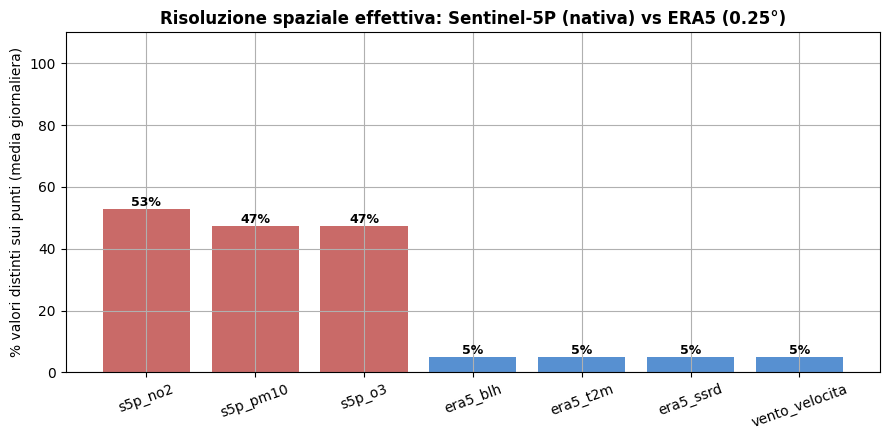

Sentinel-5P: 49% di valori distinti sui punti  (~1 valore ogni 2.0 punti)
ERA5       : 5% di valori distinti sui punti  (~1 valore ogni 20 punti, cioè la cella 0.25°)
-> il dettaglio spaziale di Sentinel-5P è circa 10 volte più fine di ERA5,
   e viene conservato: il join è a livello di punto, quindi è ERA5 a essere replicato
   sui punti. Sentinel-5P non è mai mediato, ricampionato o portato sulla griglia ERA5.


In [12]:
def valori_distinti_per_giorno(df, colonne, n_giorni=60):
    date_camp = pd.Series(CALENDARIO).sample(min(n_giorni, len(CALENDARIO)),
                                             random_state=0).sort_values()
    sub = df[df['data'].isin(date_camp)]
    righe = []
    for c in colonne:
        g = sub.groupby('data')[c].nunique()
        n_punti_g = sub.groupby('data')[c].apply(lambda s: s.notna().sum())
        quota = (g / n_punti_g.replace(0, np.nan)).mean() * 100
        righe.append({'variabile': c, 'valori distinti per giorno (media)': round(g.mean(), 1),
                      'punti validi per giorno (media)': round(n_punti_g.mean(), 1),
                      '% valori distinti': round(quota, 1)})
    return pd.DataFrame(righe)


tab_ris = valori_distinti_per_giorno(
    dati, ['s5p_no2', 's5p_pm10', 's5p_o3', 'era5_blh', 'era5_t2m', 'era5_ssrd', 'vento_velocita'])
display(tab_ris)

fig, ax = plt.subplots(figsize=(9, 4.5))
colori = [COLORI['s5p'] if v.startswith('s5p') else COLORI['era5'] for v in tab_ris['variabile']]
ax.bar(tab_ris['variabile'], tab_ris['% valori distinti'], color=colori, alpha=0.85)
for i, v in enumerate(tab_ris['% valori distinti']):
    ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=9)
ax.set_ylabel('% valori distinti sui punti (media giornaliera)')
ax.set_title('Risoluzione spaziale effettiva: Sentinel-5P (nativa) vs ERA5 (0.25°)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=20)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig(OUT_DIR / 'verifica_risoluzione_s5p.png', dpi=150, bbox_inches='tight')
plt.show()

q_s5p = tab_ris.loc[tab_ris['variabile'].str.startswith('s5p'), '% valori distinti'].mean()
q_era5 = tab_ris.loc[tab_ris['variabile'].str.startswith(('era5', 'vento')), '% valori distinti'].mean()
print(f'Sentinel-5P: {q_s5p:.0f}% di valori distinti sui punti  '
      f'(~1 valore ogni {100 / q_s5p:.1f} punti)')
print(f'ERA5       : {q_era5:.0f}% di valori distinti sui punti  '
      f'(~1 valore ogni {100 / q_era5:.0f} punti, cioè la cella 0.25°)')
print(f'-> il dettaglio spaziale di Sentinel-5P è circa {q_s5p / q_era5:.0f} volte più fine di ERA5,')
print('   e viene conservato: il join è a livello di punto, quindi è ERA5 a essere replicato')
print('   sui punti. Sentinel-5P non è mai mediato, ricampionato o portato sulla griglia ERA5.')

## 5. Matrice di progetto, valori mancanti e collinearità (VIF)

Per ogni inquinante la matrice di progetto è:

$$X = \big[\underbrace{\text{S5P}^{(L,W)}}_{\text{1 colonna, con lag}},\;
\underbrace{\text{SSRD},\; 1/\text{BLH},\; \text{T2m},\; \text{TP},\; \text{WS}}_{\text{5 colonne ERA5, giorno } t}\big]$$

**Valori mancanti:** si usa l'**analisi dei casi completi** (`dropna` sulle righe di ciascun
modello). Non si imputa: un'imputazione delle lacune S5P (nuvolosità) introdurrebbe valori non
osservati correlati alla meteorologia, cioè proprio con i predittori ERA5, distorcendo i
coefficienti.

**VIF:** `VIF_j = 1/(1 - R²_j)`, con `R²_j` della regressione del predittore *j* su tutti gli
altri. Soglie di lettura: **> 5** collinearità da sorvegliare, **> 10** collinearità forte
(coefficienti instabili e di segno poco affidabile).

In [13]:
def costruisci_dataset_modello(df, var):
    # Matrice di progetto e target per un inquinante: casi completi.
    cfg = CONFIG_S5P[var]
    colonne = ['data', 'punto_id', TARGET[var], cfg['nome_feature']] + FEATURES_ERA5
    d = df[colonne].copy()
    n_tot = len(d)
    d = d.dropna().reset_index(drop=True)
    return d, n_tot


DATASET, FEATURES = {}, {}
righe_disp = []
for var in TARGET:
    cfg = CONFIG_S5P[var]
    FEATURES[var] = [cfg['nome_feature']] + FEATURES_ERA5
    d, n_tot = costruisci_dataset_modello(dati, var)
    DATASET[var] = d
    righe_disp.append({'Inquinante': var, 'Righe totali': n_tot, 'Righe complete': len(d),
                       '% utilizzabile': round(100 * len(d) / n_tot, 2),
                       'Punti': d['punto_id'].nunique(), 'Giorni': d['data'].nunique()})

tab_disp = pd.DataFrame(righe_disp)
display(tab_disp)
tab_disp.to_csv(OUT_DIR / 'modello_disponibilita_dati.csv', sep=';', decimal=',', index=False)

,Inquinante,Righe totali,Righe complete,% utilizzabile,Punti,Giorni
0,NO2,454060,411899,90.7100,1244,341
1,O3,454060,420607,92.6300,1244,348
2,PM10,454060,429180,94.5200,1244,345
3,PM25,454060,410655,90.4400,1244,340


,Inquinante,predittore,famiglia,VIF,giudizio
0,NO2,s5p_no2_lag7_ma14,Sentinel-5P,1.5300,accettabile
1,NO2,era5_ssrd_MJ,ERA5,2.4900,accettabile
2,NO2,inv_blh,ERA5,1.4000,accettabile
3,NO2,era5_t2m_C,ERA5,1.9700,accettabile
4,NO2,era5_tp_mm,ERA5,1.2600,accettabile
5,NO2,vento_velocita,ERA5,1.0400,accettabile
6,O3,s5p_no2_lag0_ma14,Sentinel-5P,1.5700,accettabile
7,O3,era5_ssrd_MJ,ERA5,2.5100,accettabile
8,O3,inv_blh,ERA5,1.4000,accettabile
9,O3,era5_t2m_C,ERA5,1.9900,accettabile


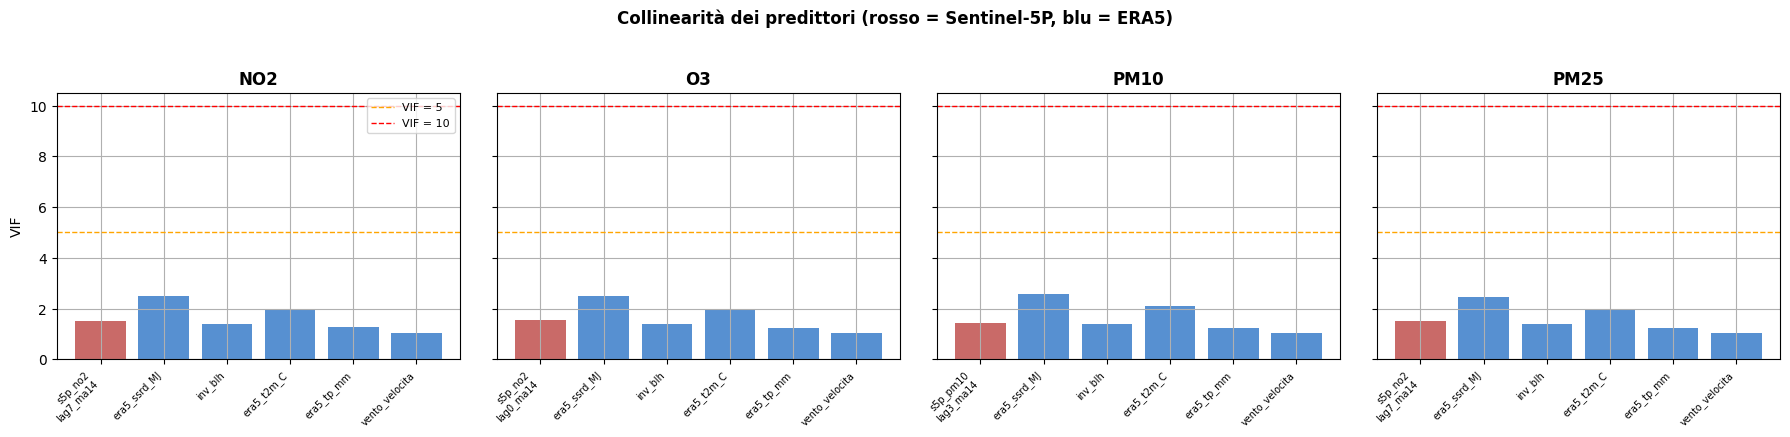

Nessun predittore con VIF > 10: i coefficienti sono interpretabili individualmente.


In [14]:
# ── VIF per ciascun modello ──────────────────────────────────────────────────
def calcola_vif(X):
    Xc = add_constant(X, has_constant='add')
    v = pd.DataFrame({'predittore': Xc.columns,
                      'VIF': [variance_inflation_factor(Xc.values, i)
                              for i in range(Xc.shape[1])]})
    return v[v['predittore'] != 'const'].reset_index(drop=True)


vif_righe = []
for var in TARGET:
    d = DATASET[var]
    # campione per contenere il costo computazionale: il VIF è stabile su ~50k righe
    Xs = d[FEATURES[var]].sample(min(50000, len(d)), random_state=0)
    v = calcola_vif(Xs)
    v['Inquinante'] = var
    v['famiglia'] = np.where(v['predittore'].str.startswith('s5p_'), 'Sentinel-5P', 'ERA5')
    vif_righe.append(v)

vif_df = pd.concat(vif_righe, ignore_index=True)[['Inquinante', 'predittore', 'famiglia', 'VIF']]
vif_df['VIF'] = vif_df['VIF'].round(2)
vif_df['giudizio'] = np.where(vif_df['VIF'] > 10, 'forte (>10)',
                              np.where(vif_df['VIF'] > 5, 'da sorvegliare (>5)', 'accettabile'))
display(vif_df)
vif_df.to_csv(OUT_DIR / 'modello_vif.csv', sep=';', decimal=',', index=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharey=True)
for ax, var in zip(axes, TARGET):
    v = vif_df[vif_df['Inquinante'] == var]
    colori = [COLORI['s5p'] if f == 'Sentinel-5P' else COLORI['era5'] for f in v['famiglia']]
    ax.bar(range(len(v)), v['VIF'], color=colori, alpha=0.85)
    ax.set_xticks(range(len(v)))
    ax.set_xticklabels([p.replace('_lag', '\nlag') for p in v['predittore']],
                       rotation=45, ha='right', fontsize=7)
    ax.axhline(5, color='orange', ls='--', lw=1, label='VIF = 5')
    ax.axhline(10, color='red', ls='--', lw=1, label='VIF = 10')
    ax.set_title(var, fontweight='bold')
axes[0].set_ylabel('VIF')
axes[0].legend(fontsize=8)
fig.suptitle('Collinearità dei predittori (rosso = Sentinel-5P, blu = ERA5)',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(OUT_DIR / 'modello_vif.png', dpi=150, bbox_inches='tight')
plt.show()

vif_alti = vif_df[vif_df['VIF'] > 10]
if len(vif_alti):
    print('ATTENZIONE — predittori con VIF > 10 (coefficienti individuali poco affidabili):')
    display(vif_alti)
else:
    print('Nessun predittore con VIF > 10: i coefficienti sono interpretabili individualmente.')

## 6. Validazione temporale senza leakage

### Schema adottato: rolling-origin con embargo

Il calendario è diviso in blocchi **contigui e ordinati nel tempo**. Per il fold *k*:

- **training** = tutti i giorni fino a `inizio_test − G` (finestra **espansiva**);
- **embargo** = `G` giorni scartati, con `G = L + W − 1` (l'ampiezza completa della finestra dei
  predittori S5P);
- **test** = il blocco *k*, sempre **successivo** al training.

**Perché serve l'embargo.** Il predittore del primo giorno di test usa dati satellitari fino a
`t − L − (W−1)` giorni prima. Senza intervallo di guardia, quei giorni apparterrebbero al periodo
di training: la stessa informazione starebbe da entrambe le parti della separazione. Scartando
`G` giorni, **nessun giorno usato per costruire una feature di test compare nel training**.

### Perché non una K-fold (né la leave-one-month-out)

Una K-fold casuale, o una leave-one-month-out, addestrano anche su periodi **successivi** al test:
il modello "vede il futuro" e, con serie fortemente autocorrelate, l'errore risulta ottimistico.
Qui la direzione del tempo è rispettata in ogni fold.

**Nota sul dominio spaziale.** La separazione è **temporale**: giorni diversi tra training e test,
tutti i punti in entrambi. Le metriche vanno quindi lette come capacità di generalizzare a
**nuovi giorni** sui punti noti, non a nuove località.

In [15]:
def crea_fold_temporali(calendario, n_fold, quota_iniziale, gap):
    # Rolling-origin espansivo: blocchi di test contigui e ordinati, con embargo di `gap` giorni.
    n = len(calendario)
    inizio = int(n * quota_iniziale)
    bordi = np.linspace(inizio, n, n_fold + 1).astype(int)
    fold = []
    for k in range(n_fold):
        i0, i1 = int(bordi[k]), int(bordi[k + 1])
        fine_train = i0 - gap
        if fine_train <= 0 or i1 <= i0:
            continue
        fold.append({
            'fold': len(fold) + 1,
            'train_inizio': calendario[0], 'train_fine': calendario[fine_train - 1],
            'embargo_inizio': calendario[fine_train], 'embargo_fine': calendario[i0 - 1],
            'test_inizio': calendario[i0], 'test_fine': calendario[i1 - 1],
            'n_giorni_train': fine_train, 'n_giorni_embargo': gap, 'n_giorni_test': i1 - i0,
        })
    return fold


FOLD = {}
righe_fold = []
for var in TARGET:
    cfg = CONFIG_S5P[var]
    gap = cfg['lag'] + cfg['ma'] - 1          # ampiezza completa della finestra dei predittori
    FOLD[var] = crea_fold_temporali(CALENDARIO, N_FOLD, QUOTA_TRAIN_INIZIALE, gap)
    for f in FOLD[var]:
        righe_fold.append({'Inquinante': var, 'Embargo [gg]': gap, **f})

tab_fold = pd.DataFrame(righe_fold)
display(tab_fold[['Inquinante', 'fold', 'train_inizio', 'train_fine', 'embargo_inizio',
                  'embargo_fine', 'test_inizio', 'test_fine',
                  'n_giorni_train', 'Embargo [gg]', 'n_giorni_test']])
tab_fold.to_csv(OUT_DIR / 'modello_fold_temporali.csv', sep=';', decimal=',', index=False)

,Inquinante,fold,train_inizio,train_fine,embargo_inizio,embargo_fine,test_inizio,test_fine,n_giorni_train,Embargo [gg],n_giorni_test
0,NO2,1,2025-01-01,2025-05-06,2025-05-07,2025-05-26,2025-05-27,2025-07-08,126,20,43
1,NO2,2,2025-01-01,2025-06-18,2025-06-19,2025-07-08,2025-07-09,2025-08-21,169,20,44
2,NO2,3,2025-01-01,2025-08-01,2025-08-02,2025-08-21,2025-08-22,2025-10-04,213,20,44
3,NO2,4,2025-01-01,2025-09-14,2025-09-15,2025-10-04,2025-10-05,2025-11-17,257,20,44
4,NO2,5,2025-01-01,2025-10-28,2025-10-29,2025-11-17,2025-11-18,2025-12-31,301,20,44
5,O3,1,2025-01-01,2025-05-13,2025-05-14,2025-05-26,2025-05-27,2025-07-08,133,13,43
6,O3,2,2025-01-01,2025-06-25,2025-06-26,2025-07-08,2025-07-09,2025-08-21,176,13,44
7,O3,3,2025-01-01,2025-08-08,2025-08-09,2025-08-21,2025-08-22,2025-10-04,220,13,44
8,O3,4,2025-01-01,2025-09-21,2025-09-22,2025-10-04,2025-10-05,2025-11-17,264,13,44
9,O3,5,2025-01-01,2025-11-04,2025-11-05,2025-11-17,2025-11-18,2025-12-31,308,13,44


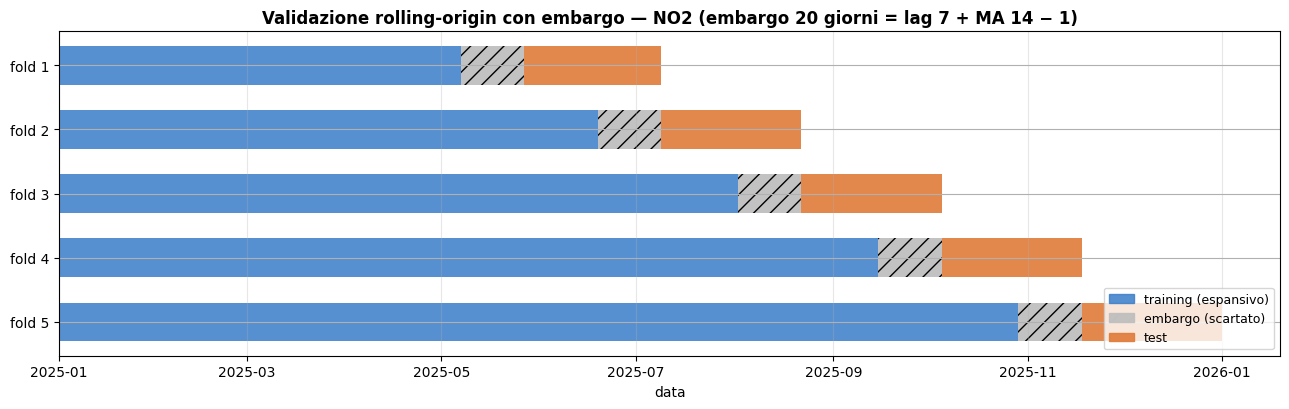

In [16]:
# ── Schema visivo della validazione (esempio: NO2, embargo più ampio) ────────
var_plot = 'NO2'
fig, ax = plt.subplots(figsize=(13, 4.2))
for f in FOLD[var_plot]:
    y = f['fold']
    ax.barh(y, (f['train_fine'] - f['train_inizio']).days + 1, left=f['train_inizio'],
            color=COLORI['train'], alpha=0.85, height=0.6)
    ax.barh(y, (f['embargo_fine'] - f['embargo_inizio']).days + 1, left=f['embargo_inizio'],
            color=COLORI['embargo'], alpha=0.95, height=0.6, hatch='//')
    ax.barh(y, (f['test_fine'] - f['test_inizio']).days + 1, left=f['test_inizio'],
            color=COLORI['test'], alpha=0.9, height=0.6)
ax.set_yticks([f['fold'] for f in FOLD[var_plot]])
ax.set_yticklabels([f"fold {f['fold']}" for f in FOLD[var_plot]])
ax.invert_yaxis()
ax.set_xlabel('data')
gap_plot = CONFIG_S5P[var_plot]['lag'] + CONFIG_S5P[var_plot]['ma'] - 1
ax.set_title(f'Validazione rolling-origin con embargo — {var_plot} '
             f"(embargo {gap_plot} giorni = lag {CONFIG_S5P[var_plot]['lag']} + "
             f"MA {CONFIG_S5P[var_plot]['ma']} − 1)", fontweight='bold')
handles = [plt.Rectangle((0, 0), 1, 1, color=COLORI['train'], alpha=0.85),
           plt.Rectangle((0, 0), 1, 1, color=COLORI['embargo'], alpha=0.95, hatch='//'),
           plt.Rectangle((0, 0), 1, 1, color=COLORI['test'], alpha=0.9)]
ax.legend(handles, ['training (espansivo)', 'embargo (scartato)', 'test'],
          loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'modello_schema_validazione.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Stima dei quattro modelli

Per ogni inquinante:

1. **Validazione temporale** — si stima il modello sul training di ciascun fold e si prevede il
   blocco di test; le previsioni dei fold vengono concatenate (**previsioni out-of-sample**).
2. **Modello finale** — ri-stima su **tutti** i dati disponibili: è il modello di cui si riportano
   equazione e coefficienti. Le metriche affidabili restano quelle out-of-sample.
3. **Modello di confronto solo-ERA5** — stessa procedura senza il predittore satellitare, per
   isolare il **contributo di Sentinel-5P** (Δ R²).

**Metriche** (con $e_i = \hat{y}_i - y_i$):

$$R^2 = 1-\frac{\sum e_i^2}{\sum (y_i-\bar y)^2}\qquad
\text{RMSE}=\sqrt{\frac{1}{n}\sum e_i^2}\qquad
\text{MAE}=\frac{1}{n}\sum |e_i|\qquad
\text{Bias}=\frac{1}{n}\sum e_i$$

Il **bias** è la media con segno degli errori: positivo = sovrastima sistematica.
`RMSE` e `MAE` sono nelle stesse unità dell'inquinante (µg/m³), quindi vanno confrontati con la
media del target.

In [17]:
def metriche(y_vero, y_stim):
    yt = np.asarray(y_vero, float)
    yp = np.asarray(y_stim, float)
    e = yp - yt
    ss_res = float((e ** 2).sum())
    ss_tot = float(((yt - yt.mean()) ** 2).sum())
    return {'n': len(yt),
            'R2': 1 - ss_res / ss_tot if ss_tot > 0 else np.nan,
            'RMSE': float(np.sqrt((e ** 2).mean())),
            'MAE': float(np.abs(e).mean()),
            'Bias': float(e.mean())}


def valida_temporale(d, features, target, fold):
    # Rolling-origin: stima sul training del fold, previsione sul blocco di test.
    X = sm.add_constant(d[features], has_constant='add')
    y = d[target]
    previsioni, per_fold = [], []
    for f in fold:
        m_tr = d['data'] <= f['train_fine']
        m_te = (d['data'] >= f['test_inizio']) & (d['data'] <= f['test_fine'])
        if m_tr.sum() < 100 or m_te.sum() < 100:
            continue
        mod = sm.OLS(y[m_tr], X[m_tr]).fit()
        yhat = mod.predict(X[m_te])
        previsioni.append(pd.DataFrame({'data': d.loc[m_te, 'data'],
                                        'punto_id': d.loc[m_te, 'punto_id'],
                                        'y': y[m_te].values, 'y_stim': yhat.values,
                                        'fold': f['fold']}))
        per_fold.append({'fold': f['fold'], 'n_train': int(m_tr.sum()),
                         'test_inizio': f['test_inizio'].date(),
                         'test_fine': f['test_fine'].date(), **metriche(y[m_te], yhat)})
    return pd.concat(previsioni, ignore_index=True), pd.DataFrame(per_fold)


MODELLI, PREVISIONI, METRICHE_FOLD = {}, {}, {}
righe_metriche, righe_coef, righe_eq = [], [], []

for var in TARGET:
    d, feats, tgt = DATASET[var], FEATURES[var], TARGET[var]

    # 1) validazione temporale (modello completo)
    prev, per_fold = valida_temporale(d, feats, tgt, FOLD[var])
    PREVISIONI[var], METRICHE_FOLD[var] = prev, per_fold

    # 2) modello finale su tutti i dati
    X = sm.add_constant(d[feats], has_constant='add')
    y = d[tgt]
    mod = sm.OLS(y, X).fit()
    MODELLI[var] = mod

    # 3) confronto solo-ERA5 (stessa validazione, senza il predittore S5P)
    prev_era5, _ = valida_temporale(d, FEATURES_ERA5, tgt, FOLD[var])

    m_ins = metriche(y, mod.fittedvalues)
    m_cv = metriche(prev['y'], prev['y_stim'])
    m_cv_era5 = metriche(prev_era5['y'], prev_era5['y_stim'])
    for etichetta, m in [('in-sample', m_ins),
                         ('validazione temporale', m_cv),
                         ('validazione temporale (solo ERA5)', m_cv_era5)]:
        righe_metriche.append({'Inquinante': var, 'stima': etichetta,
                               'media target': float(y.mean()), **m})

    # coefficienti grezzi, p-value e standardizzati (beta)
    beta = mod.params[feats] * d[feats].std() / y.std()
    for f in feats:
        righe_coef.append({'Inquinante': var, 'predittore': f,
                           'famiglia': 'Sentinel-5P' if f.startswith('s5p_') else 'ERA5',
                           'coef': float(mod.params[f]),
                           'std_err': float(mod.bse[f]),
                           'p_value': float(mod.pvalues[f]),
                           'beta_std': float(beta[f])})
    righe_coef.append({'Inquinante': var, 'predittore': 'const', 'famiglia': 'intercetta',
                       'coef': float(mod.params['const']), 'std_err': float(mod.bse['const']),
                       'p_value': float(mod.pvalues['const']), 'beta_std': np.nan})

    termini = [f"{mod.params['const']:+.6g}"] + [f"{mod.params[f]:+.6g}*{f}" for f in feats]
    righe_eq.append({'Inquinante': var, 'equazione': f'{tgt}_stim = ' + ' '.join(termini),
                     'R2_in_sample': round(m_ins['R2'], 4),
                     'R2_validazione': round(m_cv['R2'], 4),
                     'R2_validazione_solo_ERA5': round(m_cv_era5['R2'], 4),
                     'delta_R2_da_S5P': round(m_cv['R2'] - m_cv_era5['R2'], 4),
                     'RMSE_validazione': round(m_cv['RMSE'], 4),
                     'n': m_ins['n']})
    print(f"{var:5s} OK | R² in-sample {m_ins['R2']:.3f} | R² validato {m_cv['R2']:.3f} "
          f"| R² solo ERA5 {m_cv_era5['R2']:.3f} | ΔR² da S5P {m_cv['R2'] - m_cv_era5['R2']:+.3f}")

eq_df = pd.DataFrame(righe_eq)
coef_df = pd.DataFrame(righe_coef)
met_df = pd.DataFrame(righe_metriche)[['Inquinante', 'stima', 'n', 'media target',
                                       'R2', 'RMSE', 'MAE', 'Bias']]

NO2   OK | R² in-sample 0.696 | R² validato 0.664 | R² solo ERA5 0.074 | ΔR² da S5P +0.590
O3    OK | R² in-sample 0.760 | R² validato 0.717 | R² solo ERA5 0.616 | ΔR² da S5P +0.102
PM10  OK | R² in-sample 0.276 | R² validato -0.119 | R² solo ERA5 -0.255 | ΔR² da S5P +0.136
PM25  OK | R² in-sample 0.536 | R² validato 0.386 | R² solo ERA5 -0.416 | ΔR² da S5P +0.803


### 7.1 Equazioni dei modelli

Equazioni in **unità originali** (coefficienti direttamente interpretabili come variazione del
target per unità del predittore, a parità degli altri). Simboli:
`S5P` = predittore satellitare con il proprio lag e media mobile, `SSRD` = radiazione solare
[MJ/m²], `1/BLH` = inverso dello strato limite [1/m], `T2m` = temperatura [°C], `TP` =
precipitazione [mm], `WS` = velocità del vento [m/s].

In [18]:
display(eq_df[['Inquinante', 'equazione', 'R2_in_sample', 'R2_validazione']])


def simbolo(f, var):
    if f.startswith('s5p_'):
        c = CONFIG_S5P[var]
        return rf"\mathrm{{S5P}}_{{\mathrm{{{c['proxy'].replace('_', r'\_')}}}}}(t-{c['lag']},\,\mathrm{{MA}}{c['ma']})"
    return rf"\mathrm{{{SIMBOLI[f]}}}"


for var in TARGET:
    mod = MODELLI[var]
    parti = [f"{mod.params['const']:.5g}"]
    for f in FEATURES[var]:
        parti.append(f"{mod.params[f]:+.5g}\\;{simbolo(f, var)}")
    display(Math(r'\widehat{\mathrm{CAMS\;%s}} = ' % ETICHETTE[TARGET[var]].replace('.', '{.}')
                 + ' '.join(parti)))

eq_df.to_csv(OUT_DIR / 'modello_equazioni.csv', sep=';', decimal=',', index=False)

,Inquinante,equazione,R2_in_sample,R2_validazione
0,NO2,cams_no2_stim = +3.85859 +91307.4*s5p_no2_lag7...,0.6962,0.6642
1,O3,cams_o3_stim = +38.2055 -126813*s5p_no2_lag0_m...,0.7596,0.7175
2,PM10,cams_pm10_stim = +34.0018 +14.7463*s5p_pm10_la...,0.2762,-0.1194
3,PM25,cams_pm25_stim = +5.0352 +104701*s5p_no2_lag7_...,0.5357,0.3865


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 7.2 Coefficienti

Due letture distinte:

- **`coef`** (unità originali): effetto sul target di una variazione unitaria del predittore.
  Non confrontabile tra predittori con unità diverse.
- **`beta_std`** (standardizzato): effetto di **una deviazione standard** del predittore, in
  deviazioni standard del target. È la misura dell'**importanza relativa**.

Con VIF elevati (§ 5) i singoli coefficienti vanno letti con cautela: il modello nel suo
complesso resta valido, ma la ripartizione dell'effetto tra predittori correlati è instabile.

,Inquinante,predittore,famiglia,coef,std_err,p_value,beta_std
0,NO2,s5p_no2_lag7_ma14,Sentinel-5P,"91,307.3763",121.3307,0.0000,0.8003
1,NO2,era5_ssrd_MJ,ERA5,-1.5108,0.0111,0.0000,-0.1847
2,NO2,inv_blh,ERA5,10.3652,1.2947,0.0000,0.0081
3,NO2,era5_t2m_C,ERA5,0.2795,0.0014,0.0000,0.2414
4,NO2,era5_tp_mm,ERA5,-0.6891,0.0066,0.0000,-0.1006
5,NO2,vento_velocita,ERA5,-0.5152,0.0113,0.0000,-0.0398
6,NO2,const,intercetta,3.8586,0.0363,0.0000,NaN
7,O3,s5p_no2_lag0_ma14,Sentinel-5P,"-126,812.9558",292.5757,0.0000,-0.4104
8,O3,era5_ssrd_MJ,ERA5,12.2927,0.0267,0.0000,0.5487
9,O3,inv_blh,ERA5,12.3015,3.0636,0.0001,0.0036


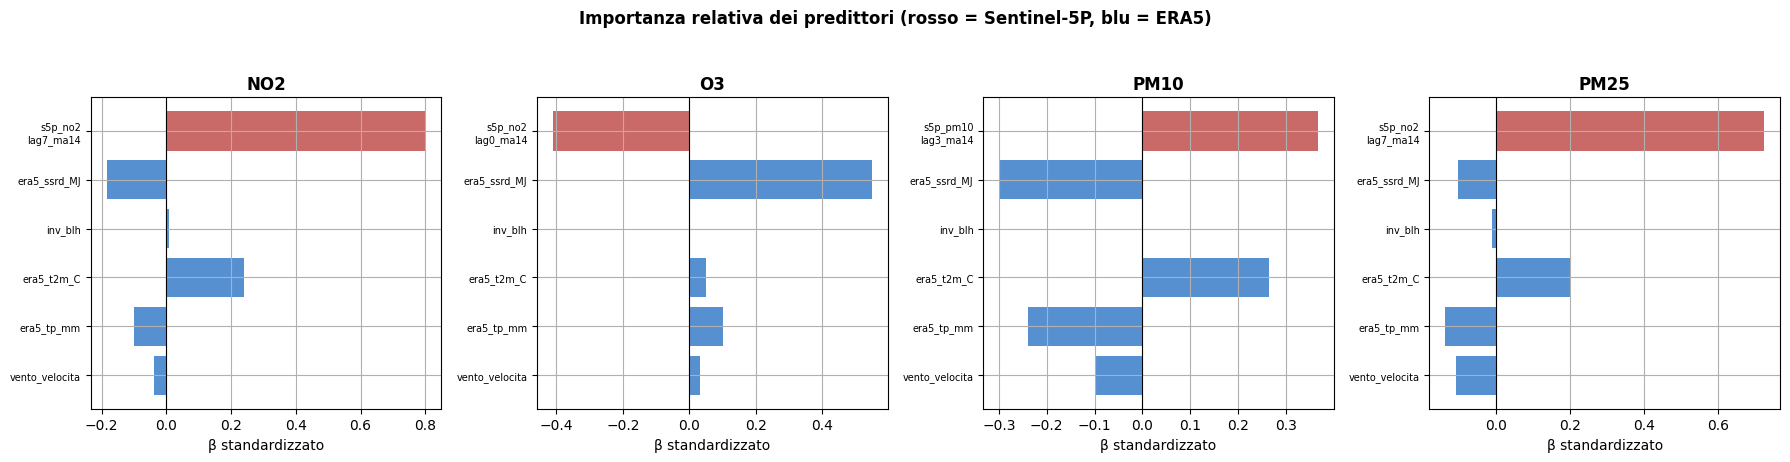

--- Summary OLS completo, esempio: NO2 ---
                            OLS Regression Results                            
Dep. Variable:               cams_no2   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                 1.573e+05
Date:                Mon, 27 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:46:55   Log-Likelihood:            -1.2615e+06
No. Observations:              411899   AIC:                         2.523e+06
Df Residuals:                  411892   BIC:                         2.523e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [19]:
display(coef_df.round(6))
coef_df.to_csv(OUT_DIR / 'modello_coefficienti.csv', sep=';', decimal=',', index=False)

# ── Importanza relativa: beta standardizzati ─────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4.4), sharey=False)
for ax, var in zip(axes, TARGET):
    c = coef_df[(coef_df['Inquinante'] == var) & (coef_df['predittore'] != 'const')]
    colori = [COLORI['s5p'] if f == 'Sentinel-5P' else COLORI['era5'] for f in c['famiglia']]
    ax.barh(range(len(c)), c['beta_std'], color=colori, alpha=0.85)
    ax.set_yticks(range(len(c)))
    ax.set_yticklabels([p.replace('_lag', '\nlag') for p in c['predittore']], fontsize=7)
    ax.invert_yaxis()
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('β standardizzato')
fig.suptitle('Importanza relativa dei predittori (rosso = Sentinel-5P, blu = ERA5)',
             fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(OUT_DIR / 'modello_coefficienti_beta.png', dpi=150, bbox_inches='tight')
plt.show()

print('--- Summary OLS completo, esempio: NO2 ---')
print(MODELLI['NO2'].summary())

### 7.3 Metriche: R², RMSE, MAE, bias

Tre righe per inquinante:

| stima | significato |
|---|---|
| **in-sample** | adattamento sui dati usati per stimare — **ottimistico**, riportato solo per confronto |
| **validazione temporale** | previsioni out-of-sample su giorni futuri, con embargo — **è questa la stima onesta** |
| **validazione temporale (solo ERA5)** | stesso schema senza Sentinel-5P — riferimento per il ΔR² |

> **Due R² diversi, entrambi necessari.** L'R² *aggregato* è calcolato su tutte le previsioni
> out-of-sample concatenate, quindi include anche la capacità di distinguere un blocco di test
> dall'altro (in pratica: la stagione). L'R² *medio per fold* misura la capacità di spiegare la
> variabilità **all'interno** di ciascun blocco. Quando il primo è molto più alto del secondo, il
> modello sta cogliendo soprattutto il **livello stagionale**, non la dinamica giorno per giorno.
> Entrambi sono riportati nella tabella di sintesi (§ 8).

In [20]:
display(met_df.round(4))
met_df.to_csv(OUT_DIR / 'modello_metriche.csv', sep=';', decimal=',', index=False)

fold_all = pd.concat([m.assign(Inquinante=v) for v, m in METRICHE_FOLD.items()],
                     ignore_index=True)
fold_all.to_csv(OUT_DIR / 'modello_metriche_per_fold.csv', sep=';', decimal=',', index=False)
print('Metriche per singolo fold (stabilità nel tempo):')
display(fold_all[['Inquinante', 'fold', 'test_inizio', 'test_fine', 'n',
                  'R2', 'RMSE', 'MAE', 'Bias']].round(4))

,Inquinante,stima,n,media target,R2,RMSE,MAE,Bias
0,NO2,in-sample,411899,12.0630,0.6962,5.1737,3.7088,0.0000
1,NO2,validazione temporale,249112,12.0630,0.6642,5.1559,3.7707,-0.5290
2,NO2,validazione temporale (solo ERA5),249112,12.0630,0.0741,8.5611,7.0042,2.3309
3,O3,in-sample,420607,55.1817,0.7596,12.4807,10.0545,-0.0000
4,O3,validazione temporale,249112,55.1817,0.7175,14.4023,11.7649,4.4841
5,O3,validazione temporale (solo ERA5),249112,55.1817,0.6159,16.7936,13.6559,2.1626
6,PM10,in-sample,429180,18.3461,0.2762,11.3896,8.4569,0.0000
7,PM10,validazione temporale,259996,18.3461,-0.1194,11.9055,10.1005,6.4797
8,PM10,validazione temporale (solo ERA5),259996,18.3461,-0.2554,12.6078,10.6396,5.3866
9,PM25,in-sample,410655,13.9327,0.5357,8.1212,5.6122,0.0000


Metriche per singolo fold (stabilità nel tempo):


,Inquinante,fold,test_inizio,test_fine,n,R2,RMSE,MAE,Bias
0,NO2,1,2025-05-27,2025-07-08,31220,0.4678,2.8667,2.3649,0.5689
1,NO2,2,2025-07-09,2025-08-21,53684,0.4195,2.7974,2.4038,0.5438
2,NO2,3,2025-08-22,2025-10-04,54736,0.4283,3.7660,2.9496,0.1142
3,NO2,4,2025-10-05,2025-11-17,54736,0.5025,6.4429,4.8551,-2.4955
4,NO2,5,2025-11-18,2025-12-31,54736,0.5420,7.2752,5.6498,-0.8841
5,O3,1,2025-05-27,2025-07-08,30168,-0.0906,16.5707,12.5707,-3.8760
6,O3,2,2025-07-09,2025-08-21,54736,-0.0637,14.2224,11.4455,-2.4622
7,O3,3,2025-08-22,2025-10-04,54736,-0.0730,12.9722,10.8632,6.8504
8,O3,4,2025-10-05,2025-11-17,54736,0.0458,15.6074,13.0200,11.5475
9,O3,5,2025-11-18,2025-12-31,54736,0.3536,13.3617,11.2869,6.6083


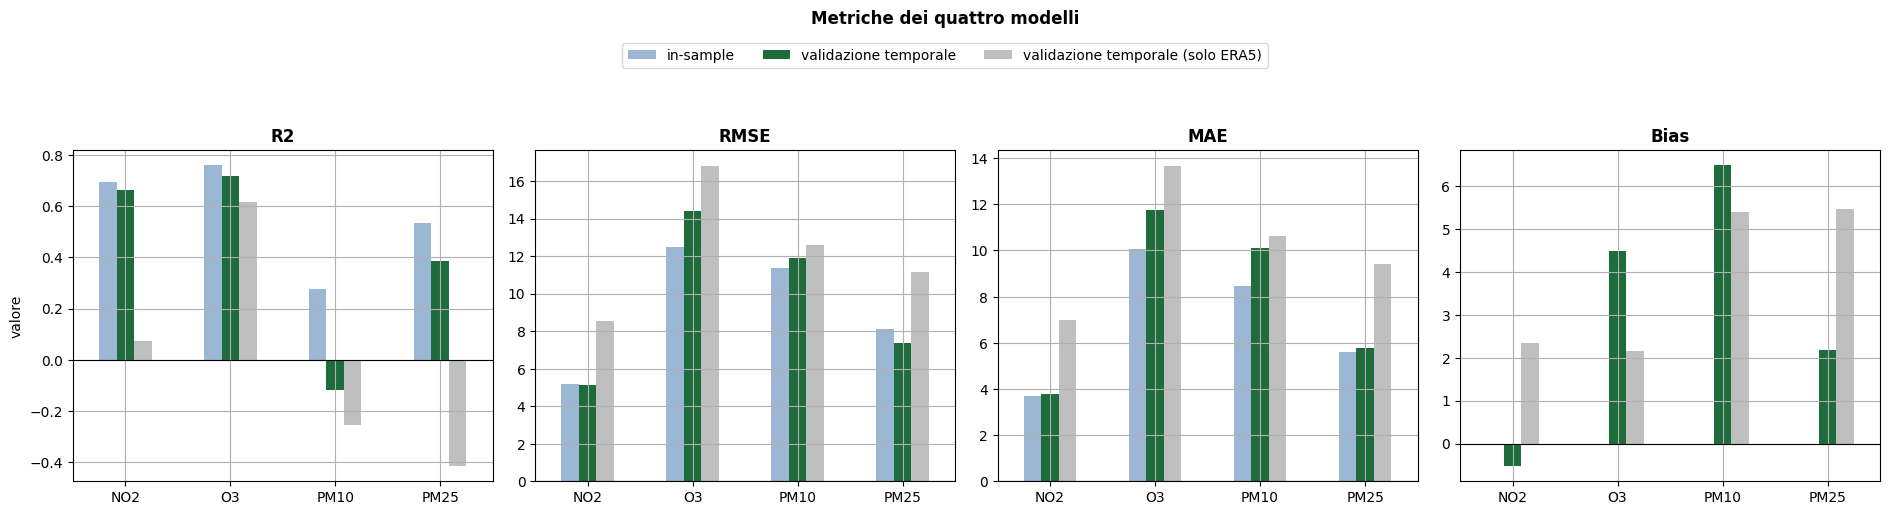

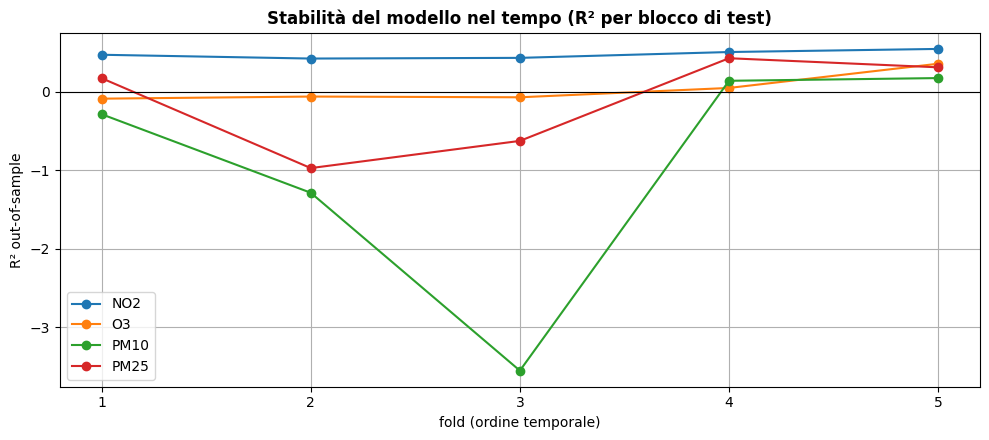

In [21]:
# ── Confronto grafico delle metriche ─────────────────────────────────────────
ordine = list(TARGET.keys())
fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))
for ax, metrica in zip(axes, ['R2', 'RMSE', 'MAE', 'Bias']):
    piv = met_df.pivot(index='Inquinante', columns='stima', values=metrica).reindex(ordine)
    piv = piv[['in-sample', 'validazione temporale', 'validazione temporale (solo ERA5)']]
    piv.plot(kind='bar', ax=ax, color=['#9BB7D4', '#1E6B3C', '#BFBFBF'], legend=False)
    ax.set_title(metrica, fontweight='bold')
    ax.axhline(0, color='black', lw=0.8)
    ax.tick_params(axis='x', rotation=0)
    ax.set_xlabel('')
axes[0].set_ylabel('valore')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.10))
fig.suptitle('Metriche dei quattro modelli', fontweight='bold', y=1.16)
plt.tight_layout()
plt.savefig(OUT_DIR / 'modello_metriche.png', dpi=150, bbox_inches='tight')
plt.show()

# ── R² per fold: stabilità temporale ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
for var in ordine:
    m = METRICHE_FOLD[var]
    ax.plot(m['fold'], m['R2'], marker='o', label=var)
ax.set_xlabel('fold (ordine temporale)')
ax.set_ylabel('R² out-of-sample')
ax.set_xticks(sorted(fold_all['fold'].unique()))
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Stabilità del modello nel tempo (R² per blocco di test)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'modello_r2_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Diagnostica dei residui

Per ogni inquinante, sulle **previsioni out-of-sample**: dispersione previsto vs osservato
(la retta rossa è la bisettrice, non un fit) e residui contro il valore previsto.
Una struttura a imbuto o una curvatura nei residui segnalano eteroschedasticità o non linearità
residua, cioè margine di miglioramento del modello lineare.

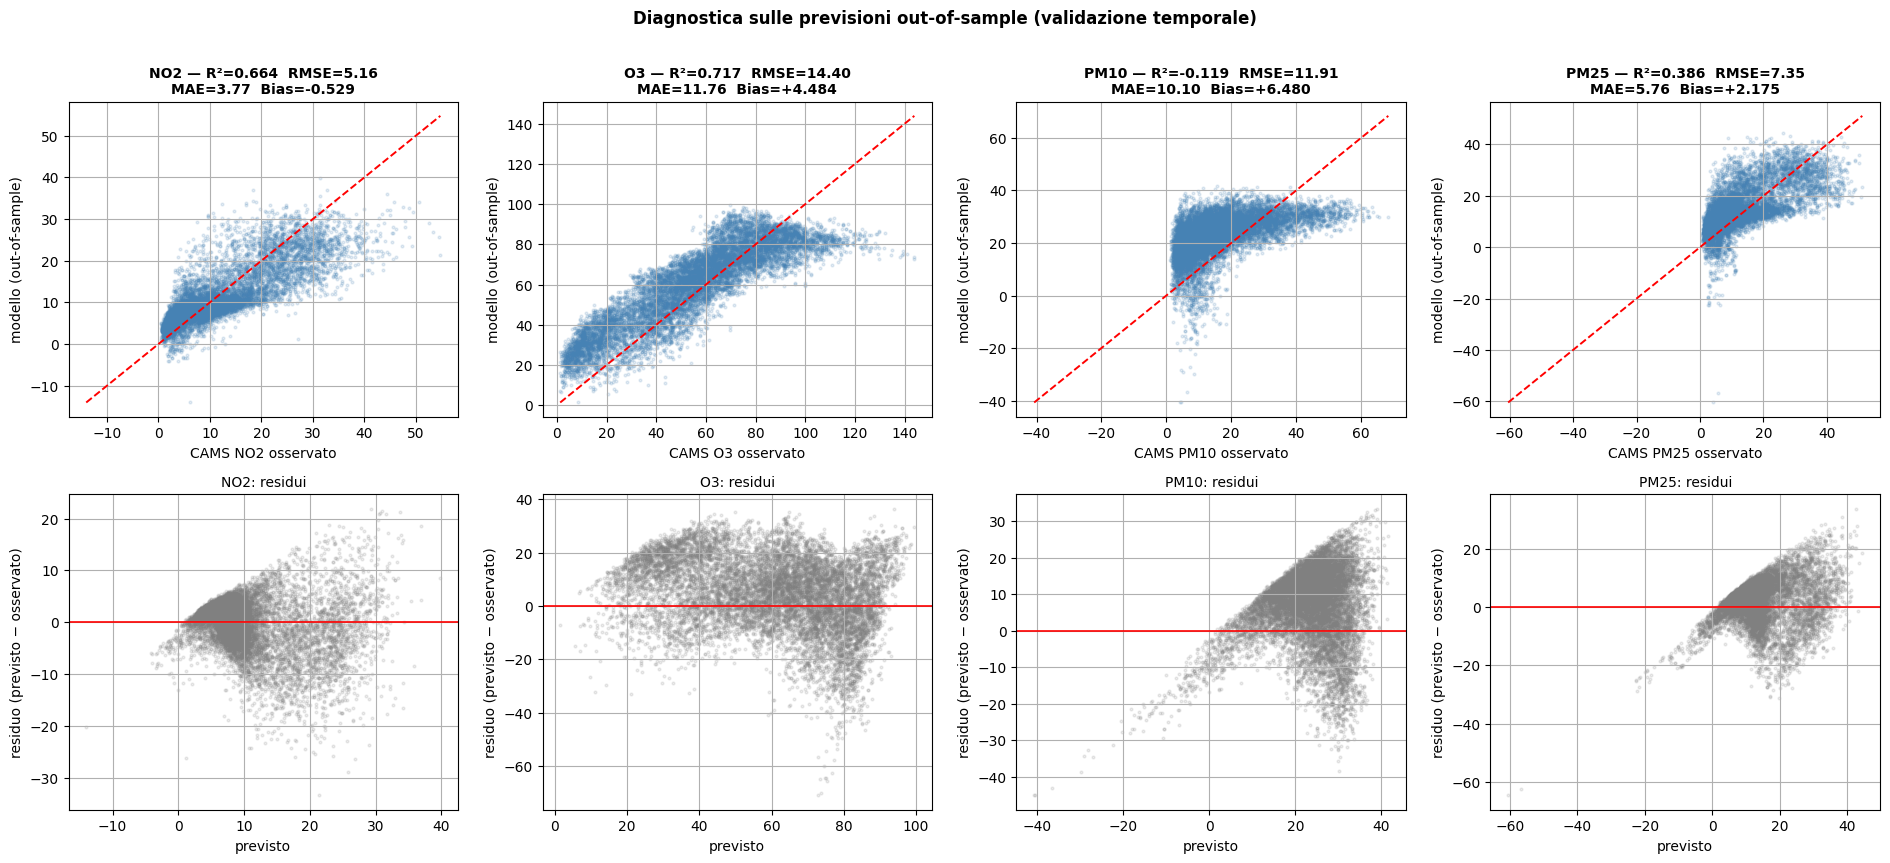

In [22]:
rng = np.random.default_rng(7)
fig, axes = plt.subplots(2, 4, figsize=(19, 8.5))
for j, var in enumerate(ordine):
    p = PREVISIONI[var]
    idx = rng.choice(len(p), min(12000, len(p)), replace=False)
    yy, pp = p['y'].values[idx], p['y_stim'].values[idx]

    ax = axes[0, j]
    ax.scatter(yy, pp, s=4, alpha=0.15, color='steelblue', rasterized=True)
    lim = [min(yy.min(), pp.min()), max(yy.max(), pp.max())]
    ax.plot(lim, lim, 'r--', lw=1.4)
    m = metriche(p['y'], p['y_stim'])
    ax.set_title(f"{var} — R²={m['R2']:.3f}  RMSE={m['RMSE']:.2f}\n"
                 f"MAE={m['MAE']:.2f}  Bias={m['Bias']:+.3f}", fontsize=10, fontweight='bold')
    ax.set_xlabel(f'CAMS {var} osservato')
    ax.set_ylabel('modello (out-of-sample)')

    ax = axes[1, j]
    res = pp - yy
    ax.scatter(pp, res, s=4, alpha=0.15, color='grey', rasterized=True)
    ax.axhline(0, color='red', lw=1.2)
    ax.set_xlabel('previsto')
    ax.set_ylabel('residuo (previsto − osservato)')
    ax.set_title(f'{var}: residui', fontsize=10)
fig.suptitle('Diagnostica sulle previsioni out-of-sample (validazione temporale)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'modello_diagnostica_residui.png', dpi=150, bbox_inches='tight')
plt.show()

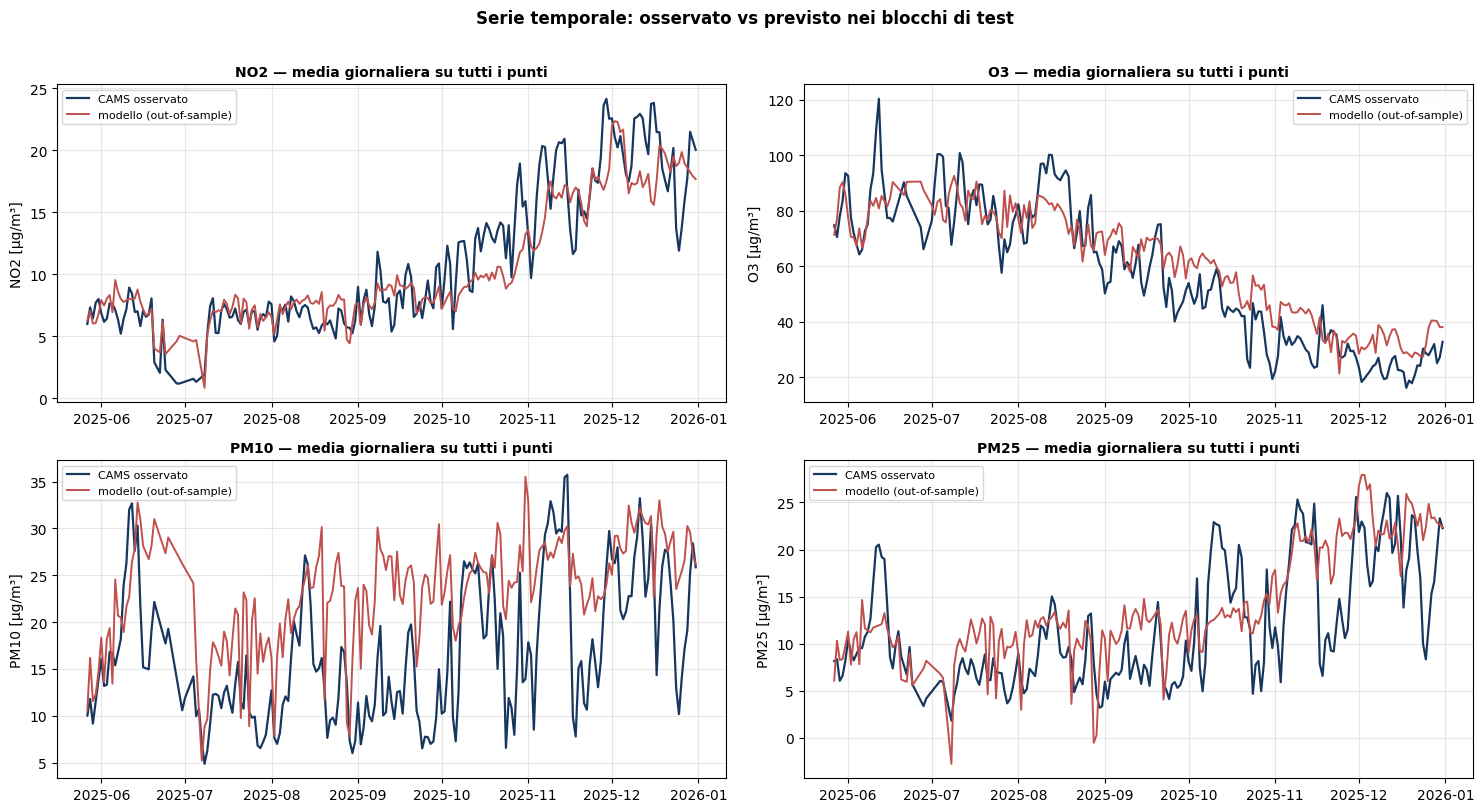

In [23]:
# ── Andamento temporale: media giornaliera osservata vs prevista (out-of-sample) ──
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, var in zip(axes.ravel(), ordine):
    p = PREVISIONI[var]
    g = p.groupby('data')[['y', 'y_stim']].mean()
    ax.plot(g.index, g['y'], color='#17375E', lw=1.6, label='CAMS osservato')
    ax.plot(g.index, g['y_stim'], color='#C0504D', lw=1.4, label='modello (out-of-sample)')
    ax.set_title(f'{var} — media giornaliera su tutti i punti', fontsize=10, fontweight='bold')
    ax.set_ylabel(f'{var} [µg/m³]')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle('Serie temporale: osservato vs previsto nei blocchi di test', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'modello_serie_temporale.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Tabella di sintesi

In [24]:
sintesi = []
for var in ordine:
    cfg = CONFIG_S5P[var]
    cv = met_df[(met_df['Inquinante'] == var) & (met_df['stima'] == 'validazione temporale')].iloc[0]
    ins = met_df[(met_df['Inquinante'] == var) & (met_df['stima'] == 'in-sample')].iloc[0]
    era5 = met_df[(met_df['Inquinante'] == var) &
                  (met_df['stima'] == 'validazione temporale (solo ERA5)')].iloc[0]
    sintesi.append({
        'Inquinante': var,
        'Predittore S5P': f"{cfg['proxy']} (lag {cfg['lag']}, MA {cfg['ma']})",
        'Predittori ERA5': f'{len(FEATURES_ERA5)} al giorno t',
        'n': int(cv['n']),
        'media target': round(cv['media target'], 2),
        'R² in-sample': round(ins['R2'], 3),
        'R² validato (aggregato)': round(cv['R2'], 3),
        'R² validato (medio per fold)': round(float(METRICHE_FOLD[var]['R2'].mean()), 3),
        'ΔR² da S5P': round(cv['R2'] - era5['R2'], 3),
        'RMSE': round(cv['RMSE'], 2),
        'MAE': round(cv['MAE'], 2),
        'Bias': round(cv['Bias'], 3),
        'RMSE / media [%]': round(100 * cv['RMSE'] / cv['media target'], 1),
    })
tab_sintesi = pd.DataFrame(sintesi)
display(tab_sintesi)
tab_sintesi.to_csv(OUT_DIR / 'modello_sintesi.csv', sep=';', decimal=',', index=False)

print('\nFile salvati in', OUT_DIR.resolve())
for f in sorted(OUT_DIR.iterdir()):
    print('  ', f.name)

,Inquinante,Predittore S5P,Predittori ERA5,n,media target,R² in-sample,R² validato (aggregato),R² validato (medio per fold),ΔR² da S5P,RMSE,MAE,Bias,RMSE / media [%]
0,NO2,"NO2_TROPOMI (lag 7, MA 14)",5 al giorno t,249112,12.0600,0.6960,0.6640,0.4720,0.5900,5.1600,3.7700,-0.5290,42.7000
1,O3,"NO2_proxy (lag 0, MA 14)",5 al giorno t,249112,55.1800,0.7600,0.7170,0.0340,0.1020,14.4000,11.7600,4.4840,26.1000
2,PM10,"Aerosol_Index (lag 3, MA 14)",5 al giorno t,259996,18.3500,0.2760,-0.1190,-0.9630,0.1360,11.9100,10.1000,6.4800,64.9000
3,PM25,"NO2_proxy (lag 7, MA 14)",5 al giorno t,247868,13.9300,0.5360,0.3860,-0.1400,0.8030,7.3500,5.7600,2.1750,52.7000



File salvati in C:\Users\nsarmientoospina\Documents\REG4IA\risultati_modello
   modello_coefficienti.csv
   modello_coefficienti_beta.png
   modello_diagnostica_residui.png
   modello_disponibilita_dati.csv
   modello_equazioni.csv
   modello_fold_temporali.csv
   modello_metriche.csv
   modello_metriche.png
   modello_metriche_per_fold.csv
   modello_r2_per_fold.png
   modello_schema_validazione.png
   modello_serie_temporale.png
   modello_sintesi.csv
   modello_vif.csv
   modello_vif.png
   qc_copertura_s5p_mensile.png
   qc_valori_mancanti.png
   verifica_risoluzione_s5p.png


## 9. Come leggere i risultati (e cosa non concludere)

**Sulle metriche**
- Fa fede la riga **validazione temporale**: è l'unica calcolata su giorni mai visti in fase di
  stima, con l'embargo che esclude anche l'informazione entrata nelle finestre dei predittori.
- Il divario tra **in-sample** e **validato** misura quanto il modello dipende dal periodo di
  stima. Un divario ampio indica adattamento a condizioni non ripetibili.
- **RMSE/media** rende l'errore confrontabile tra inquinanti con scale diverse.
- Il **bias** vicino a zero indica assenza di sotto/sovrastima sistematica; un bias marcato e
  crescente tra i fold segnala deriva stagionale non catturata dai predittori.

**Un R² negativo è un risultato, non un errore.** `R² < 0` significa che, su quel blocco di test,
il modello sbaglia più della semplice media del target: non generalizza a quel periodo. Con uno
schema rolling-origin questo è frequente nei **primi fold**, dove il training copre solo i mesi
freddi e il test cade in estate: il modello viene chiesto di **estrapolare** fuori dall'intervallo
di condizioni su cui è stato stimato. Il segnale diagnostico da guardare è il **bias per fold**
(tabella § 7.3): un bias grande e di segno costante indica uno **scarto di livello** stagionale,
non un errore casuale.

**Perché questi numeri sono più bassi di quelli del notebook esplorativo.** Il notebook ERA5–CAMS
valuta con *leave-one-month-out*: ogni mese di test è circondato da mesi di training
**precedenti e successivi**, quindi il modello interpola dentro un anno che ha già visto per
intero. Qui il training precede sempre il test e l'embargo scarta i giorni di raccordo: è una
domanda più difficile, e la differenza tra i due risultati **è la misura del leakage** che lo
schema precedente lasciava passare. I valori più bassi non indicano un modello peggiore, ma una
stima più onesta dello stesso modello.

**Sul contributo di Sentinel-5P**
- Il **ΔR²** confronta lo stesso schema di validazione con e senza il predittore satellitare: è la
  misura del valore aggiunto dell'osservazione da satellite rispetto alla sola meteorologia.
- Un ΔR² modesto **non** significa che il satellite sia inutile: la parte di segnale condivisa con
  la meteorologia viene attribuita ai predittori ERA5, che entrano al giorno *t* e senza lacune.

**Limiti da dichiarare insieme ai risultati**
1. **Il target è CAMS, non una misura.** ERA5 e CAMS condividono la meteorologia IFS: una quota
   dell'adattamento riflette la costruzione interna di CAMS. Le colonne `arpa_*` presenti nel
   dataset consentirebbero una validazione contro misure indipendenti: è un'analisi diversa,
   non svolta qui.
2. **Separazione temporale, non spaziale.** Le metriche descrivono la generalizzazione a nuovi
   **giorni**, non a nuove **località**. Per quest'ultima servirebbe una validazione con punti
   esclusi dal training.
3. **Lag e finestre sono ereditati**, selezionati sull'intero 2025 nel notebook temporale: la
   loro scelta non è stata ri-validata fuori campione, quindi una quota residua di ottimismo
   sulla configurazione resta possibile.
4. **Casi completi.** I giorni con lacuna satellitare escono dal campione; poiché le lacune sono
   dovute alla nuvolosità, il campione è lievemente sbilanciato verso condizioni di cielo sereno.
5. **Modello lineare.** Relazioni note come non lineari (BLH, forma a U del PM con la
   temperatura) sono colte solo in parte: `1/BLH` linearizza la diluizione, ma termini quadratici
   o modelli non lineari restano un'estensione naturale.
6. **Umidità relativa assente** dal dataset: limitazione dichiarata, non stimata con proxy.